# Crude Oil Price Forecasting Pipeline

End-to-end implementation: EDA → Feature Engineering → LSTM Model → Training → Streamlit Dashboard

---

## Phase 1: Exploratory Data Analysis (EDA)

In [1]:
# Phase 1: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
# Phase 1: Load Data
df = pd.read_csv('Crude_Oil.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')
df.head()

Shape: (6435, 7)
Date range: 2000-08-23 → 2026-04-10


,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility
Date,,,,,,,
2000-08-23,31.950001,32.799999,31.950001,32.049999,79385,0.00,0.85
2000-08-24,31.900000,32.240002,31.400000,31.629999,72978,-1.31,0.84
2000-08-25,31.700001,32.099998,31.320000,32.049999,44601,1.33,0.78
2000-08-28,32.040001,32.919998,31.860001,32.869999,46770,2.56,1.06
2000-08-29,32.820000,33.029999,32.560001,32.720001,49131,-0.46,0.47


In [3]:
# Phase 1: Data Integrity Check
print('Missing values:')
print(df.isnull().sum())
print(f'\nZero-volume days: {(df["Volume"] == 0).sum()}')
df.info()

Missing values:
Open                   0
High                   0
Low                    0
Close                  0
Volume                 0
Daily_Return_%         0
Intraday_Volatility    0
dtype: int64

Zero-volume days: 13
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6435 entries, 2000-08-23 to 2026-04-10
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Open                 6435 non-null   float64
 1   High                 6435 non-null   float64
 2   Low                  6435 non-null   float64
 3   Close                6435 non-null   float64
 4   Volume               6435 non-null   int64  
 5   Daily_Return_%       6435 non-null   float64
 6   Intraday_Volatility  6435 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 402.2 KB


In [4]:
# Phase 1: Outlier Detection (Z-Score)
outlier_cols = []
for col in ['Daily_Return_%', 'Volume']:
    z = np.abs(stats.zscore(df[col]))
    outliers = df[z > 5]
    print(f'{col}: {len(outliers)} outliers (Z > 5)')
    if len(outliers) > 0:
        print(outliers[[col]].head(3))
        outlier_cols.extend(outliers.index.tolist())
print(f'\nTotal black swan events flagged: {len(set(outlier_cols))}')

Daily_Return_%: 7 outliers (Z > 5)
            Daily_Return_%
Date                      
2020-03-09          -24.59
2020-04-02           24.67
2020-04-20         -305.97
Volume: 3 outliers (Z > 5)
             Volume
Date               
2019-09-16  1404916
2020-03-09  1774383
2020-04-21  2288230

Total black swan events flagged: 8


In [5]:
# Phase 1: Stationarity Test (ADF)
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'{name}: ADF={result[0]:.4f}, p={result[1]:.4f} → Stationary: {"Yes" if result[1] < 0.05 else "No"}')

adf_test(df['Close'], 'Close')
adf_test(df['Daily_Return_%'], 'Returns')

Close: ADF=-2.8496, p=0.0515 → Stationary: No
Returns: ADF=-14.8601, p=0.0000 → Stationary: Yes


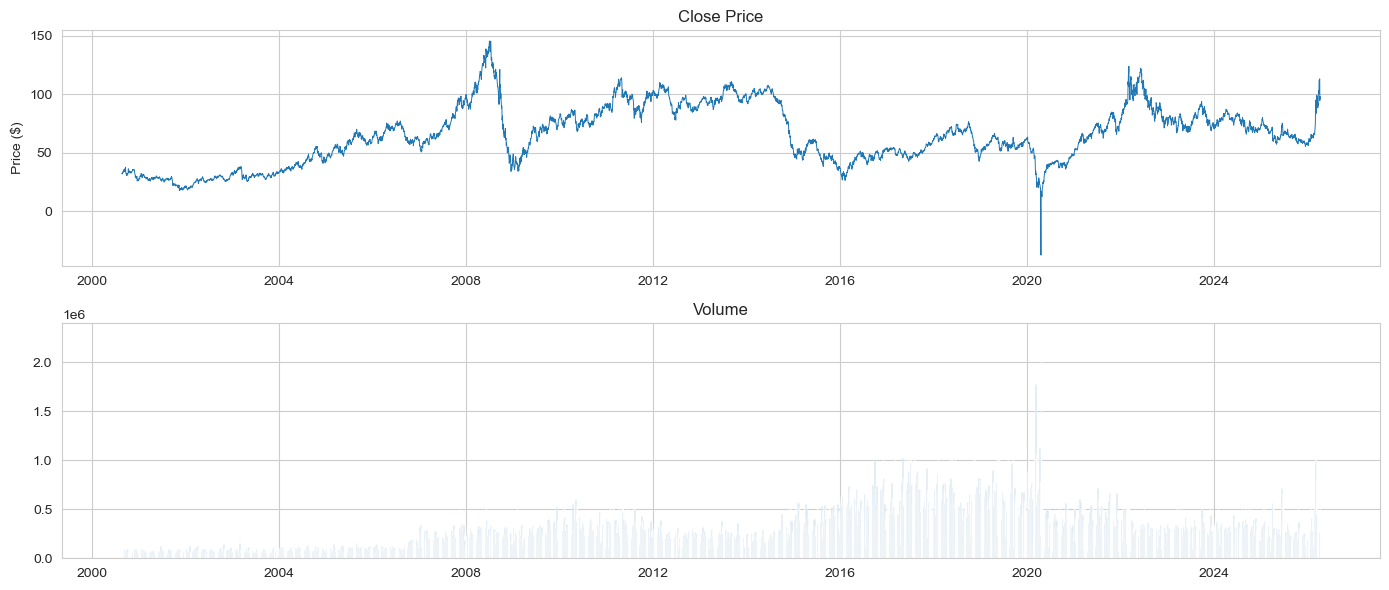

In [6]:
# Phase 1: Visualizations
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(df.index, df['Close'], linewidth=0.7)
axes[0].set_title('Close Price')
axes[0].set_ylabel('Price ($)')
axes[1].bar(df.index, df['Volume'], width=1, alpha=0.6)
axes[1].set_title('Volume')
plt.tight_layout()
plt.show()

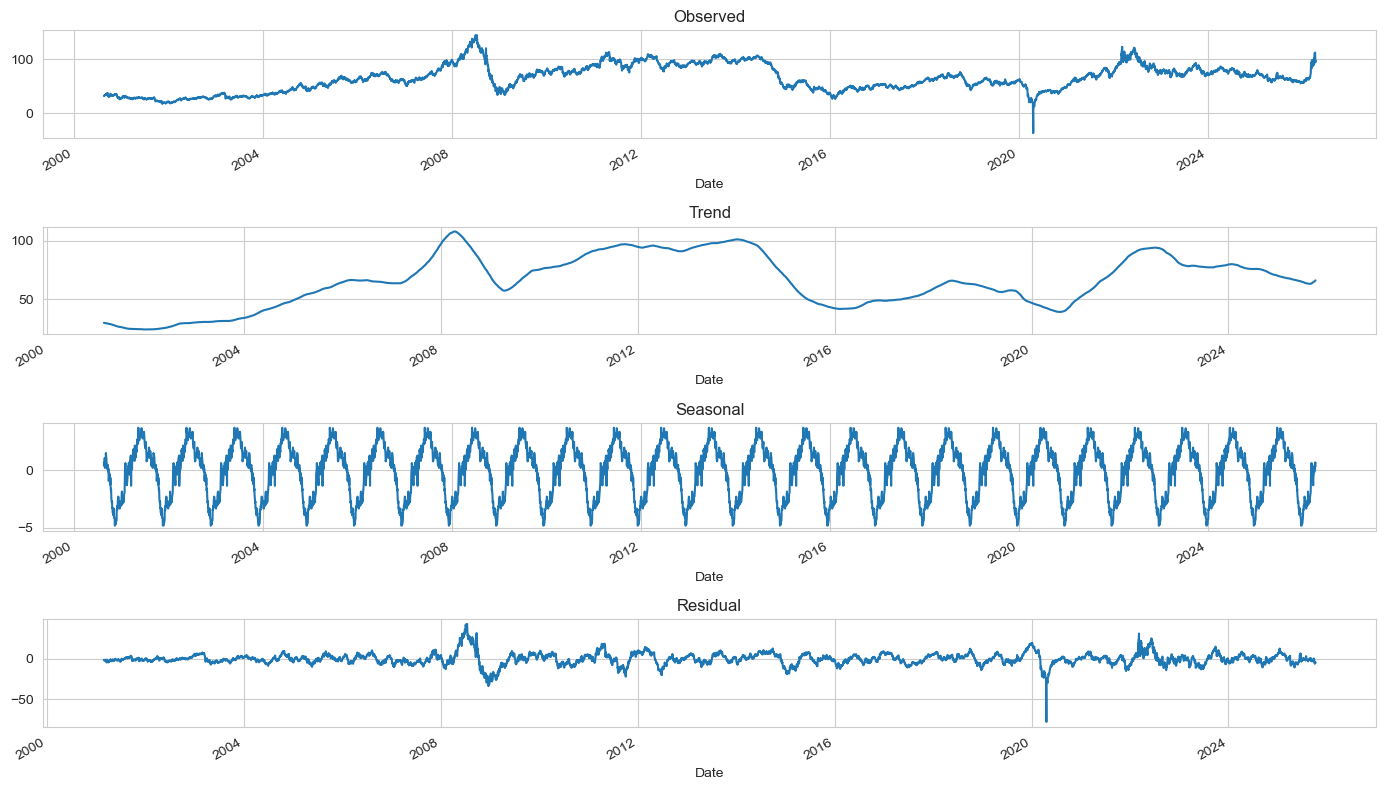

In [7]:
# Phase 1: Time Series Decomposition
decomp = seasonal_decompose(df['Close'], model='additive', period=252)
fig, axes = plt.subplots(4, 1, figsize=(14, 8))
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Seasonal')
decomp.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

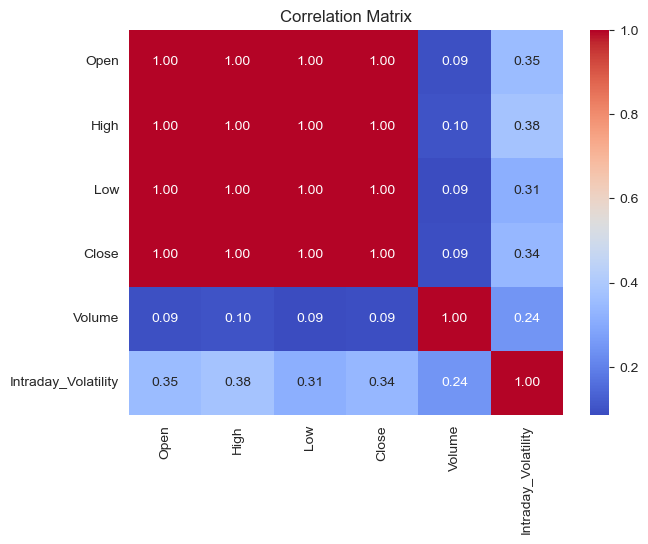

In [8]:
# Phase 1: Correlation Matrix
cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Intraday_Volatility']
plt.figure(figsize=(7, 5))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Phase 1 Summary
- Data loaded: ~6,400 rows, Aug 2000 → present
- No missing values in price columns
- Black swan outliers detected (2008 crisis, Apr 2020) — flagged, NOT removed
- Close price: non-stationary | Returns: stationary

---

## Phase 2: Feature Engineering & Preprocessing

In [9]:
# Phase 2: Create copy for processing
data = df.copy()
print(f'Working copy shape: {data.shape}')

Working copy shape: (6435, 7)


In [10]:
# Phase 2: Handle missing/zero values
# Forward fill price columns
price_cols = ['Open', 'High', 'Low', 'Close']
for col in price_cols:
    data[col] = data[col].ffill()
# Fill volume with 7-day rolling median
data['Volume'] = data['Volume'].replace(0, np.nan)
data['Volume'] = data['Volume'].fillna(data['Volume'].rolling(7, min_periods=1).median())
# Fill remaining NaNs
data = data.fillna(method='ffill').fillna(method='bfill')
print(f'After cleaning: {data.isnull().sum().sum()} missing values')

After cleaning: 0 missing values


In [11]:
# Technical Indicators (manual calculation)
close = data['Close']
high = data['High']
low = data['Low']

# RSI-14
delta = close.diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
data['RSI_14'] = 100 - (100 / (1 + rs))

# MACD
ema_12 = close.ewm(span=12, adjust=False).mean()
ema_26 = close.ewm(span=26, adjust=False).mean()
data['MACD'] = ema_12 - ema_26
data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

# SMA
data['SMA_20'] = close.rolling(20).mean()
data['SMA_50'] = close.rolling(50).mean()
data['SMA_200'] = close.rolling(200).mean()
data['EMA_20'] = close.ewm(span=20, adjust=False).mean()

# Bollinger Bands
bb_mid = close.rolling(20).mean()
bb_std = close.rolling(20).std()
data['BB_Upper'] = bb_mid + 2 * bb_std
data['BB_Lower'] = bb_mid - 2 * bb_std
data['BB_Width'] = data['BB_Upper'] - data['BB_Lower']

# ATR
tr1 = high - low
tr2 = (high - close.shift()).abs()
tr3 = (low - close.shift()).abs()
tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
data['ATR'] = tr.rolling(14).mean()

print('Technical indicators added successfully')

Technical indicators added successfully


In [12]:
# Phase 2: Time-based cyclical features
close = data['Close']
data['DayOfWeek'] = data.index.dayofweek
data['Month'] = data.index.month
data['Quarter'] = data.index.quarter

# Cyclical encoding (sin/cos)
data['DayOfWeek_sin'] = np.sin(2 * np.pi * data['DayOfWeek'] / 5)
data['DayOfWeek_cos'] = np.cos(2 * np.pi * data['DayOfWeek'] / 5)
data['Month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
data['Month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)
data['Quarter_sin'] = np.sin(2 * np.pi * data['Quarter'] / 4)
data['Quarter_cos'] = np.cos(2 * np.pi * data['Quarter'] / 4)

# Additional lagged features
for lag in [1, 3, 7, 14]:
    data[f'Close_Lag{lag}'] = close.shift(lag)
    data[f'Return_Lag{lag}'] = data['Close'].pct_change(lag).shift(lag)

# Volume features
data['Volume_Lag1'] = data['Volume'].shift(1)
data['Volume_MA5'] = data['Volume'].rolling(5).mean()

print(f'Features now: {data.shape[1]} columns')

Features now: 37 columns


In [13]:
# Phase 2: Drop rows with NaN (from indicators)
data_clean = data.dropna().copy()
print(f'After dropping NaN: {data_clean.shape}')
data_clean.head()

After dropping NaN: (6236, 37)


,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility,RSI_14,MACD,MACD_Signal,...,Close_Lag1,Return_Lag1,Close_Lag3,Return_Lag3,Close_Lag7,Return_Lag7,Close_Lag14,Return_Lag14,Volume_Lag1,Volume_MA5
Date,,,,,,,,,,,,,,,,,,,,,
2001-06-11,28.750000,29.340000,28.400000,29.040001,85621.0,2.25,0.94,40.126069,-0.007787,0.044811,...,28.400000,0.023423,27.719999,-0.007519,28.370001,-0.053702,29.980000,0.035936,47763.0,70837.2
2001-06-12,28.879999,29.379999,28.750000,29.180000,62998.0,0.48,0.63,43.991424,0.053657,0.046581,...,29.040001,0.022535,27.750000,-0.013509,27.930000,-0.060861,29.740000,0.069784,85621.0,71326.0
2001-06-13,29.500000,29.629999,28.809999,28.840000,78197.0,-1.17,0.82,42.355378,0.074064,0.052077,...,29.180000,0.004821,28.400000,0.005666,28.129999,-0.049020,29.580000,0.039719,62998.0,66856.4
2001-06-14,28.840000,29.280001,28.600000,29.040001,62964.0,0.69,0.68,58.139543,0.105162,0.062694,...,28.840000,-0.011652,29.040001,0.047619,28.240000,-0.005984,28.410000,0.001763,78197.0,67508.6
2001-06-15,29.049999,29.110001,28.440001,28.510000,58361.0,-1.83,0.67,51.487425,0.086049,0.067365,...,29.040001,0.006935,29.180000,0.051532,27.719999,-0.023256,28.379999,0.021966,62964.0,69628.2


In [14]:
# Phase 2: Train/Val/Test Split (temporal, no shuffle)
n = len(data_clean)
train_size = int(n * 0.70)
val_size = int(n * 0.15)

train_data = data_clean.iloc[:train_size]
val_data = data_clean.iloc[train_size:train_size+val_size]
test_data = data_clean.iloc[train_size+val_size:]

print(f'Train: {train_data.shape[0]} ({train_data.index.min().date()} → {train_data.index.max().date()})')
print(f'Val:   {val_data.shape[0]} ({val_data.index.min().date()} → {val_data.index.max().date()})')
print(f'Test:  {test_data.shape[0]} ({test_data.index.min().date()} → {test_data.index.max().date()})')

Train: 4365 (2001-06-11 → 2018-10-30)
Val:   935 (2018-10-31 → 2022-07-20)
Test:  936 (2022-07-21 → 2026-04-10)


In [15]:
# Phase 2: Scaling (MinMaxScaler)
from sklearn.preprocessing import MinMaxScaler

# Features to scale
feature_cols = [c for c in data_clean.columns if c not in ['DayOfWeek', 'Month', 'Quarter']]
print(f'Features to scale: {len(feature_cols)}')

# Fit scaler on TRAIN ONLY
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data[feature_cols])

# Transform all sets
train_scaled = scaler.transform(train_data[feature_cols])
val_scaled = scaler.transform(val_data[feature_cols])
test_scaled = scaler.transform(test_data[feature_cols])

# Scaler for Close price separately (for inverse transform)
close_scaler = MinMaxScaler(feature_range=(0, 1))
close_scaler.fit(train_data[['Close']])
print('Scaling complete')

Features to scale: 34
Scaling complete


In [16]:
# Phase 2: Time Series Windowing (Sequence Creation)
SEQ_LENGTH = 60  # 60 days lookback

def create_sequences(features, target_col_idx, seq_length):
    """Convert 2D array to 3D tensors [samples, seq_len, features]"""
    X, y = [], []
    for i in range(seq_length, len(features)):
        X.append(features[i-seq_length:i])
        y.append(features[i, target_col_idx])
    return np.array(X), np.array(y)

# Find Close index in feature_cols
close_idx = feature_cols.index('Close')

# Create sequences
X_train, y_train = create_sequences(train_scaled, close_idx, SEQ_LENGTH)
X_val, y_val = create_sequences(val_scaled, close_idx, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, close_idx, SEQ_LENGTH)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val: {X_val.shape}, y_val: {y_val.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (4305, 60, 34), y_train: (4305,)
X_val: (875, 60, 34), y_val: (875,)
X_test: (876, 60, 34), y_test: (876,)


### Phase 2 Summary
- Features engineered: RSI, MACD, SMAs, EMA, Bollinger Bands, ATR, cyclical time features
- Split: Train 70% | Val 15% | Test 15% (temporal)
- Scalers fitted on TRAIN only
- Sequences created: 60-day lookback windows

---

## Phase 3: LSTM Model Architecture

In [17]:
# Phase 3: Build LSTM Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.19.0


In [18]:
# Phase 3: Model Architecture
model = Sequential([
    # Layer 1: LSTM 128 units
    LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4), input_shape=(SEQ_LENGTH, len(feature_cols))),
    Dropout(0.3),
    
    # Layer 2: LSTM 64 units
    LSTM(64, return_sequences=False, kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    
    # Layer 3: Dense 32
    Dense(32, activation='relu'),
    
    # Output: Single value
    Dense(1, activation='linear')
])

model.compile(
    optimizer=Adam(learning_rate=0.001, amsgrad=True),
    loss=Huber()
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        83,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,977 (527.25 KB)

 Trainable params: 134,977 (527.25 KB)

 Non-trainable params: 0 (0.00 B)

### Phase 3 Summary
- Architecture: LSTM(128) → Dropout(0.3) → LSTM(64) → Dropout(0.2) → Dense(32) → Dense(1)
- Regularization: L2 on LSTM layers
- Loss: Huber (robust to outliers)
- Optimizer: Adam with amsgrad

---

## Phase 4: Training & Evaluation

In [19]:
# Phase 4: Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
]

In [20]:
# Phase 4: Train Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,  # Early stopping will handle
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.0379 - val_loss: 0.0182 - learning_rate: 0.0010
Epoch 2/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0170 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 3/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0124 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 4/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.0097 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 5/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0079 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 6/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0066 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 7/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0057 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 8/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0049 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 9/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0044 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 10/1

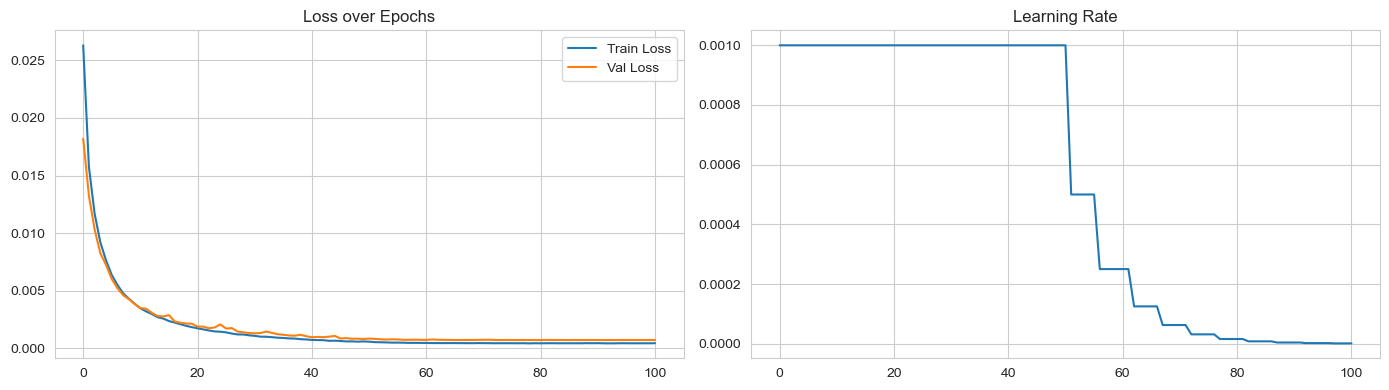

In [21]:
# Phase 4: Plot Training History

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss plot
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

# Learning rate plot (FIXED SAFE VERSION)
if 'learning_rate' in history.history:
    axes[1].plot(history.history['learning_rate'])
    axes[1].set_title('Learning Rate')
else:
    axes[1].text(0.5, 0.5, 'Learning rate not tracked', 
                 ha='center', va='center')
    axes[1].set_title('Learning Rate')

plt.tight_layout()
plt.show()

In [22]:
# Phase 4: Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on test set
y_pred = model.predict(X_test).flatten()

# Inverse transform to original scale
y_test_inv = close_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_inv = close_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print(f'Test RMSE: ${rmse:.2f}')
print(f'Test MAE:  ${mae:.2f}')
print(f'Test MAPE: {mape:.2f}%')

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step
Test RMSE: $2.76
Test MAE:  $1.95
Test MAPE: 2.59%


In [23]:
# Phase 4: Save Model
model.save('crude_oil_lstm.keras')
print('Model saved to crude_oil_lstm.keras')

Model saved to crude_oil_lstm.keras


### Phase 4 Summary
- Training with EarlyStopping & ReduceLROnPlateau
- Evaluated on held-out test set
- Model saved

---

## Phase 5: Multi-Step Forecasting Engine

In [24]:
# Phase 5: Load model for inference
model = tf.keras.models.load_model('crude_oil_lstm.keras')
print('Model loaded')

Model loaded


In [25]:
# Phase 5: Recursive Multi-Step Forecasting
def forecast_n_days(model, last_sequence, n_days, feature_cols, scaler):
    """Forecast n days into the future recursively"""
    predictions = []
    current_seq = last_sequence.copy()
    
    for _ in range(n_days):
        # Predict next day
        pred = model.predict(current_seq.reshape(1, -1, len(feature_cols)), verbose=0)
        predictions.append(pred[0, 0])
        
        # Update sequence: drop first day, add prediction
        # Note: This is simplified - real impl needs proper feature engineering for each step
        new_row = current_seq[-1].copy()
        new_row[-1] = pred[0, 0]  # Replace Close with prediction
        current_seq = np.vstack([current_seq[1:], new_row])
    
    return np.array(predictions)

# Get last 60 days from test data
last_seq = X_test[-1]

# Forecast 7 days
forecast_7 = forecast_n_days(model, last_seq, 7, feature_cols, close_scaler)
forecast_7_inv = close_scaler.inverse_transform(forecast_7.reshape(-1, 1)).flatten()

print('7-Day Forecast:')
for i, price in enumerate(forecast_7_inv, 1):
    print(f'  Day +{i}: ${price:.2f}')

7-Day Forecast:
  Day +1: $102.12
  Day +2: $99.44
  Day +3: $97.18
  Day +4: $95.85
  Day +5: $95.66
  Day +6: $96.59
  Day +7: $98.44


### Phase 5 Summary
- Recursive forecasting: last 60 days → predict day t+1 → use prediction for t+2 → etc
- Confidence degrades exponentially further out